# Handling Duplicate Data

`04_Data_Cleaning.MD` names this as sub-skill #5 — genuinely new ground,
not covered by any earlier notebook (`06`–`14` were all about *missing*
values and outliers, never repeated rows). Its own table draws a sharp
line between two different problems that both get called "duplicates":

| Type | What it looks like | Fix |
|---|---|---|
| **Exact duplicates** | Two rows, every column identical | Drop one copy |
| **Near-duplicates** | Same real record, different text — `"Apple"` vs `"APPLE "` | Normalize first, *then* compare |

Section 1 builds a small 6-row example where both cases are visible at
once. Section 2 runs the exact-duplicate check on the real `loans.csv`.
Section 3 sanity-checks for near-duplicates too.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## 1. The Mechanics — A Small, Controlled Example

Six students, two subjects. Two rows (`0` and `4`) are planted as **exact**
duplicates — same name, same marks in both subjects. Two more (`2` and `5`)
share a name and an `eng` score but differ in `hindi` — a **partial**
match, not a true duplicate, deliberately included to show how the
`subset` parameter can get this wrong.

In [2]:
data = {
    "name":  ["a", "b", "c", "d", "a", "c"],
    "eng":   [8,   7,   5,   8,   8,   4],
    "hindi": [2,   3,   4,   5,   2,   6],
}
df = pd.DataFrame(data)
df

,name,eng,hindi
0,a,8,2
1,b,7,3
2,c,5,4
3,d,8,5
4,a,8,2
5,c,4,6


Row `4` is byte-for-byte identical to row `0` (`a`, `8`, `2`) — a
real duplicate. Row `5` looks similar to row `2` (`c`, `5`) but its
`hindi` score is `6`, not `4` — a *different* record that happens to
share two of three columns. Keep an eye on both as the checks below
run.

In [3]:
df.duplicated()

0    False
1    False
2    False
3    False
4     True
5    False
dtype: bool

`duplicated()` compares **every column** and returns one boolean per
row: `True` if that exact combination already appeared earlier in the
DataFrame. Default behaviour is `keep="first"` — the *first* time a
combination shows up it's the original (`False`); every repeat after that
is flagged (`True`). Only row `4` comes back `True` here — it's the only
row that matches an earlier row on *all* columns. Row `5` stays `False`,
because `hindi` breaks the match with row `2`.

In [4]:
df.duplicated(keep="last")

0     True
1    False
2    False
3    False
4    False
5    False
dtype: bool

Same comparison, opposite choice of "which copy is the original."
With `keep="last"`, the *last* occurrence of a combination is treated as
the one to keep, so now row `0` flips to `True` and row `4` flips to
`False` — the pair is the same, only which one counts as "the duplicate"
changed.

In [5]:
df.duplicated(keep=False)

0     True
1    False
2    False
3    False
4     True
5    False
dtype: bool

`keep=False` stops picking a "keeper" altogether — *every* row that
belongs to a duplicate set is marked `True`, first occurrence included.
Both row `0` and row `4` come back `True` here; useful when the goal is
"flag anything involved in a duplicate," not "flag the extras."

In [6]:
df.duplicated(subset=["name", "eng"])

0    False
1    False
2    False
3    False
4     True
5    False
dtype: bool

`subset` narrows the comparison to just the listed columns. Compared
on `name` + `eng` only, row `5` (`c`, `5`) now matches row `2` (`c`, `5`)
— `hindi` is no longer part of the comparison, so the fact that they
differ there (`4` vs `6`) is invisible to this check. This is exactly the
risk `04_Data_Cleaning.MD` doesn't spell out but implies: narrowing the
subset can turn two genuinely different records into "duplicates."

### Now actually removing them — `drop_duplicates()`

Same three `keep` choices, but this time returning a filtered DataFrame
instead of a boolean mask.

In [7]:
df.drop_duplicates()

,name,eng,hindi
0,a,8,2
1,b,7,3
2,c,5,4
3,d,8,5
5,c,4,6


Default `keep="first"`: row `4` is gone, the other 5 rows remain —
including *both* row `2` and row `5`, since comparing on all columns
correctly sees them as different records.

In [8]:
df.drop_duplicates(keep=False)

,name,eng,hindi
1,b,7,3
2,c,5,4
3,d,8,5
5,c,4,6


`keep=False` removes **both** copies of any exact duplicate, not
just the extra one — row `0` and row `4` are *both* gone, leaving 4 rows.
This is the right call when neither copy can be trusted (which one is the
"real" one is unknowable), not just when there's one too many.

In [9]:
df.drop_duplicates(subset=["name", "eng"])

,name,eng,hindi
0,a,8,2
1,b,7,3
2,c,5,4
3,d,8,5
5,c,4,6


Also 4 rows left — but for a different reason than `keep=False`
above. Here row `5` is dropped alongside row `4`, and row `5` was **not**
an exact duplicate — its `hindi = 6` was real, distinct information,
discarded because `subset` never looked at that column. Same row count as
the previous cell, two very different (and not equally safe) outcomes.

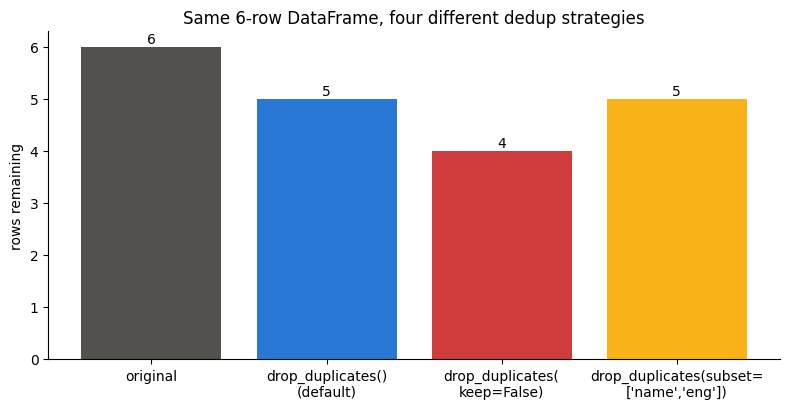

In [10]:
strategies = {
    "original":                          df.shape[0],
    "drop_duplicates()\n(default)":       df.drop_duplicates().shape[0],
    "drop_duplicates(\nkeep=False)":      df.drop_duplicates(keep=False).shape[0],
    "drop_duplicates(subset=\n['name','eng'])": df.drop_duplicates(subset=["name", "eng"]).shape[0],
}

plt.figure(figsize=(8, 4.2))
bars = plt.bar(strategies.keys(), strategies.values(),
                color=["#52514e", "#2a78d6", "#d03b3b", "#fab219"])
plt.ylabel("rows remaining")
plt.title("Same 6-row DataFrame, four different dedup strategies")
for b in bars:
    plt.text(b.get_x() + b.get_width()/2, b.get_height() + 0.07,
              str(int(b.get_height())), ha="center")
plt.gca().spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

Same starting data, four different "correct" answers — deduplication
isn't one fixed operation, it's a decision about which columns define "the
same row" and which copy (if any) is worth keeping.

## 2. Checking `loans.csv` for Real Duplicates

In [11]:
dataset = pd.read_csv("loans.csv")
dataset.shape

(618, 13)

In [12]:
dataset.duplicated().sum()

np.int64(0)

**0.** No two of the 618 rows match on all 13 columns — including
`Loan_ID`, which is already unique per applicant by design, so a full-row
duplicate here would require the exact same ID appearing twice. It
doesn't.

In [13]:
cols_without_id = [c for c in dataset.columns if c != "Loan_ID"]
dataset.duplicated(subset=cols_without_id).sum()

np.int64(0)

Still **0** — a stronger check than the one above. This asks "did
two *different* applicants (different `Loan_ID`) happen to submit
identical values on every other field?", ignoring the one column that's
guaranteed unique. Comes back clean too: `loans.csv` genuinely has no
duplicate rows, exact or otherwise. That's a real finding, not a failed
check — worth confirming explicitly rather than assuming.

In [14]:
dataset.drop_duplicates(inplace=True)
dataset.shape

(618, 13)

`(618, 13) → (618, 13)`, unchanged — nothing to remove, as expected.
`inplace=True` is safe to use here: this is a direct call on the whole
`dataset` object, not the `dataset["col"].fillna(..., inplace=True)`
pattern `15_Feature_Scaling.ipynb` found silently broken under pandas'
Copy-on-Write — that bug was specific to mutating a *column selection*,
not the DataFrame itself.

## 3. Seeing It Actually Remove Something

`loans.csv` has no real duplicates to demonstrate on, so — the way
`04_Data_Cleaning.MD` frames it ("two identical loan applications from a
scraping glitch") — deliberately re-introduce a few, and confirm
`drop_duplicates()` finds exactly those and nothing else.

In [15]:
glitchy = pd.concat([dataset, dataset.sample(5, random_state=42)], ignore_index=True)
glitchy.shape

(623, 13)

**623** rows — the original 618 plus 5 rows sampled from the same
data and appended a second time, simulating a scraping glitch that
submitted the same application twice.

In [16]:
glitchy.duplicated().sum()

np.int64(5)

**5** — exactly the 5 rows that now exist twice. Nothing else in
the 618 original rows got miscounted as a duplicate.

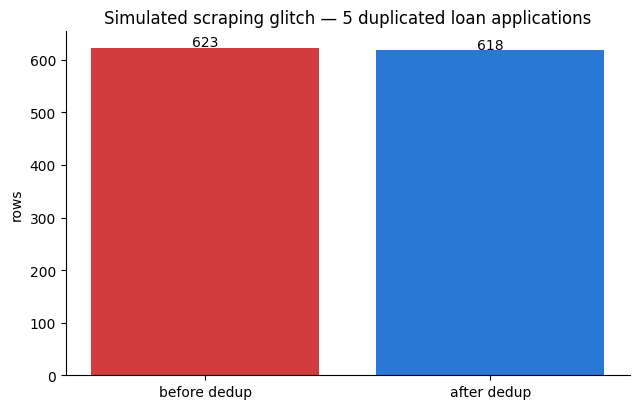

In [17]:
fig, ax = plt.subplots(figsize=(6.5, 4.2))
counts = {"before dedup": glitchy.shape[0],
          "after dedup":  glitchy.drop_duplicates().shape[0]}
bars = ax.bar(counts.keys(), counts.values(), color=["#d03b3b", "#2a78d6"])
ax.set_ylabel("rows")
ax.set_title("Simulated scraping glitch — 5 duplicated loan applications")
for b in bars:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 3,
             str(int(b.get_height())), ha="center")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

In [18]:
glitchy.drop_duplicates(inplace=True)
glitchy.shape

(618, 13)

Back to **`(618, 13)`** — exactly the original clean shape.
`drop_duplicates()` removed precisely the 5 artificial repeats and no real
row got caught in the crossfire.

## 4. Near-Duplicates — A Quick Sanity Check

`duplicated()` only catches **exact** string matches. `04_Data_Cleaning.MD`'s
`"Apple"` vs `"APPLE "` example would sail straight through it — two rows
that are the same real category, spelled differently, are just two
different strings as far as `duplicated()` is concerned. Before trusting
the "0 duplicates" result above, check whether any categorical column in
`loans.csv` actually has that problem.

In [19]:
for col in ["Gender", "Married", "Dependents", "Education",
            "Self_Employed", "Property_Area", "Loan_Status"]:
    print(col, "->", sorted(dataset[col].dropna().unique().tolist()))

Gender -> ['Female', 'Male']
Married -> ['No', 'Yes']
Dependents -> ['0', '1', '2', '3+']
Education -> ['Graduate', 'Not Graduate']
Self_Employed -> ['No', 'Yes']
Property_Area -> ['Rural', 'Semiurban', 'Urban']
Loan_Status -> ['N', 'Y']


Every column already has one consistent spelling per category —
`"Male"`/`"Female"`, never a `"male"`/`"Male"` mix; `"Yes"`/`"No"`, never
`"yes"`/`"Yes "`. No normalizing needed here. Worth checking explicitly,
though: a mixed-case column would have silently defeated the exact-match
`duplicated()` calls in Section 2 — `"Male"` and `"male"` read as two
different values, not one category counted twice.

## Summary

- `duplicated()` flags repeats; `drop_duplicates()` removes them — both
  default to comparing **every** column and keeping the **first**
  occurrence (`keep="first"`).
- `keep="last"` flips which copy survives; `keep=False` drops **every**
  member of a duplicate set, not just the extras.
- `subset=[...]` narrows which columns count toward "the same row" — and
  can silently treat genuinely different records as duplicates if the
  ignored columns actually differ (Section 1's row `5`).
- `loans.csv` has **zero** exact duplicates, checked two ways (with and
  without `Loan_ID`), and no near-duplicate spelling issues in any
  categorical column either — confirmed by running the checks, not
  assumed.
- `inplace=True` is safe on a direct `dataset.drop_duplicates(...)` call —
  unlike the chained `dataset["col"].fillna(..., inplace=True)` pattern
  `15_Feature_Scaling.ipynb` found silently broken under Copy-on-Write.